# Getting Started with the MoistX API

MoistX provides satellite-derived **surface soil moisture** (0–5 cm depth) fusing data from
**Sentinel-1**, **Sentinel-2**, and **Landsat 8/9**.

In this notebook you will:
- Authenticate with the MoistX API using an API key
- Query soil moisture for a single point
- Parse the JSON response into a pandas DataFrame
- Build an interactive time series coloured by satellite sensor and marked by quality flag

## Prerequisites

Install dependencies (run once):
```bash
pip install -r requirements.txt
```

Get your API key from [moistx.com/dashboard](https://moistx.com/dashboard), then copy and paste
it to `.env` or set `MOISTX_API_KEY=your_key` in it. The setup cell below
loads it automatically via `python-dotenv`.

Full endpoint reference: [Swagger UI](https://moistx.com/api/docs) /
[ReDoc](https://moistx.com/api/redoc). Data is free to use/share/modify (including
commercially) with attribution to MoistX and the underlying satellite sources — see the
repo [README](./README.md#data-license--attribution) for the exact wording.


In [1]:
import os
import requests
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from dotenv import load_dotenv

# Interactive chart in Jupyter/VS Code, plus a static PNG copy saved with the output so
# the chart also shows on GitHub (which doesn't run JavaScript). The PNG needs kaleido
# and Chrome (`pip install kaleido`, then `plotly_get_chrome`); without them, charts
# are just interactive.
try:
    pio.to_image({'data': []}, format='png')
    pio.renderers.default = 'plotly_mimetype+png'
except Exception:
    pass

load_dotenv()

BASE_URL = 'https://moistx.com/api'
API_KEY  = os.getenv('MOISTX_API_KEY')
if not API_KEY:
    raise RuntimeError(
        'MOISTX_API_KEY not set — add your key to .env '
        '(get one from https://moistx.com/dashboard)'
    )
HEADERS  = {'X-Api-Key': API_KEY}


## Location and time range

The API accepts:
- `latitude` / `longitude` — decimal degrees, WGS84
- `start_datetime` / `end_datetime` — ISO 8601 format (`YYYY-MM-DDTHH:MM:SS`)
- Maximum window: **365 days** per request


## Fetching soil moisture data


In [2]:
LATITUDE  = 39.55
LONGITUDE = 22.30
START     = '2025-04-01T00:00:00'
END       = '2025-09-30T00:00:00'

In [3]:
response = requests.get(
    f'{BASE_URL}/get/point/soil-moisture',
    headers=HEADERS,
    params={
        'latitude':       LATITUDE,
        'longitude':      LONGITUDE,
        'start_datetime': START,
        'end_datetime':   END,
    },
)
response.raise_for_status()
data = response.json()
print(f'Received {len(data)} observations')

Received 76 observations


## Understanding the response

Each entry in the JSON response maps a timestamp to a dictionary with:
- `sm_0_5cm` — volumetric soil moisture at 0–5 cm depth (vol%)
- `source` — the data source of the file: `S2`, `S1_asc`, `S1_desc`, `L89`, or `harmonized` (a combined estimate from multiple sensors, used by some regions)
- `sensors` — the sensors that contributed to the value at **this pixel**: any of `Sentinel-1 ascending`, `Sentinel-1 descending`, `Sentinel-2`, `Landsat-8/9`. For harmonized data this tells you which sensors were actually blended at your point
- `quality` — NDVI quality flag from the most recent valid optical NDVI (Sentinel-2 or Landsat-8/9) within 30 days: `good` (NDVI < 0.75) or `poor` (NDVI ≥ 0.75, dense vegetation — the estimate is less reliable)

`sensors` and `quality` are `null` in regions where this information is not (yet) available.

In [4]:
sample_key = next(iter(data))
entry = data[sample_key]
print('Timestamp :', sample_key)
print('  sm_0_5cm:', entry['sm_0_5cm'], 'vol%')
print('  source  :', entry['source'])
print('  sensors :', entry.get('sensors'))
print('  quality :', entry.get('quality'))

Timestamp : 2025-04-04T09:30:00
  sm_0_5cm: 29.9 vol%
  source  : harmonized
  sensors : None
  quality : None


## Building a DataFrame


In [5]:
records = [
    {
        'datetime':      pd.to_datetime(ts),
        'soil_moisture': v['sm_0_5cm'],
        'source':        v['source'],
        # e.g. ['Sentinel-2', 'Landsat-8/9'] → 'Sentinel-2 + Landsat-8/9'
        'sensors':       ' + '.join(v['sensors']) if v.get('sensors') else 'not available',
        'quality':       v.get('quality') or 'not available',
    }
    for ts, v in data.items()
]
df = pd.DataFrame(records).set_index('datetime').sort_index()

print('Date range :', df.index.min().date(), 'to', df.index.max().date())
print('Sources    :', sorted(df['source'].unique()))
print('Sensors    :', sorted(df['sensors'].unique()))
print('Quality    :', df['quality'].value_counts().to_dict())
df.head()

Date range : 2025-04-04 to 2025-09-01
Sources    : ['harmonized']
Sensors    : ['not available']
Quality    : {'not available': 76}


,soil_moisture,source,sensors,quality
datetime,,,,
2025-04-04 09:30:00,29.9,harmonized,not available,not available
2025-04-05 09:30:00,29.9,harmonized,not available,not available
2025-04-06 09:30:00,24.4,harmonized,not available,not available
2025-04-09 09:30:00,32.4,harmonized,not available,not available
2025-04-10 09:30:00,29.8,harmonized,not available,not available


## Interactive time series

Each dot represents one satellite acquisition. Colour indicates the sensors that
contributed at this point; **hollow** markers are acquisitions flagged as `poor` quality
(dense vegetation, NDVI ≥ 0.75). Hover over any point to see the exact date, soil moisture
value, sensors and quality.

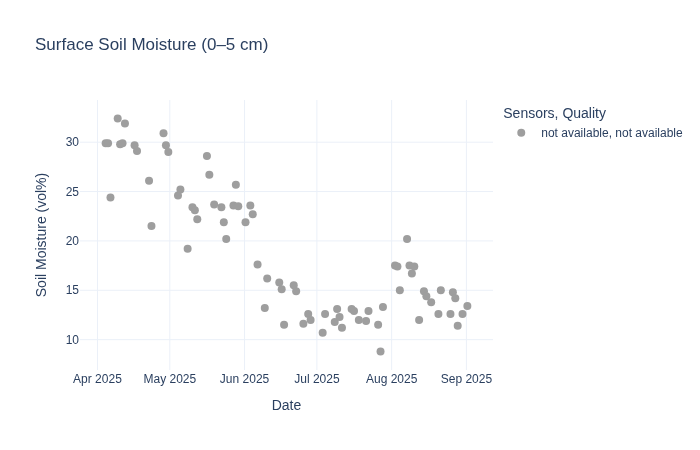

In [6]:
SENSOR_COLORS = {
    'Sentinel-2':            '#4CAF50',
    'Sentinel-1 ascending':  '#2196F3',
    'Sentinel-1 descending': '#7B1FA2',
    'Landsat-8/9':           '#FF9800',
    'not available':         '#9E9E9E',
}
QUALITY_SYMBOLS = {'good': 'circle', 'poor': 'circle-open', 'unknown': 'x', 'not available': 'circle'}

fig = px.scatter(
    df.reset_index(),
    x='datetime',
    y='soil_moisture',
    color='sensors',
    color_discrete_map=SENSOR_COLORS,  # sensor combinations get the default palette
    symbol='quality',
    symbol_map=QUALITY_SYMBOLS,
    title='Surface Soil Moisture (0–5 cm)',
    labels={
        'soil_moisture': 'Soil Moisture (vol%)',
        'datetime': 'Date',
        'sensors': 'Sensors',
        'quality': 'Quality',
    },
)
fig.update_traces(marker_size=8)
fig.update_layout(height=450, template='plotly_white', hovermode='x unified')
fig.show()

## Sensor coverage and quality summary

Number of acquisitions and soil moisture statistics per sensor combination, split by
quality flag.

In [7]:
summary = df.groupby(['sensors', 'quality']).agg(
    observations=('soil_moisture', 'count'),
    mean_sm=('soil_moisture', 'mean'),
    min_sm=('soil_moisture', 'min'),
    max_sm=('soil_moisture', 'max'),
).round(1)
summary

,,observations,mean_sm,min_sm,max_sm
sensors,quality,,,,
not available,not available,76,18.9,8.8,32.4
